# B1 / P 모델 비교 분석
Confusion Matrix + Attention HeatmapMap

## 0. 환경설정

In [ ]:
!pip install tf_keras tensorflow_hub scikit-learn -q
!pip install transformers==4.40.0 -q
!apt-get install -y fonts-nanum -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras
from tf_keras import layers
from transformers import AutoTokenizer, TFRobertaModel
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 한글 폰트
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 드라이브 마운트 및 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/multimodel_recycle/output'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
VAL_CSV = os.path.join(BASE_DIR, 'val.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test.csv')
B1_MODEL_PATH = os.path.join(BASE_DIR, 'b1_best.keras')
P_MODEL_PATH = os.path.join(BASE_DIR, 'p_best.keras')
ROBERTA_MODEL_PATH = os.path.join(BASE_DIR, 'roberta_finetuned')

IMG_SIZE = 224
BATCH_SIZE = 16
MAX_LEN = 64
SEED = 42

GROUP_NAMES = {
    0:'종이', 1:'종이팩', 2:'종이컵', 3:'캔',
    4:'재사용유리', 5:'유리', 6:'페트', 7:'플라스틱', 8:'비닐',
    9:'종이+이물질', 10:'종이컵+이물질', 11:'캔+이물질', 12:'유리+이물질',
    13:'페트+이물질+다중포장재', 14:'페트+이물질', 15:'플라스틱+이물질', 16:'비닐+이물질',
    17:'재사용유리+다중포장재', 18:'유리+다중포장재', 19:'페트+다중포장재',
    20:'스티로폼', 21:'스티로폼+이물질', 22:'건전지',
}
labels = list(GROUP_NAMES.values())
print('설정 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
설정 완료


## 2. 테스트 데이터 로드 및 경로 수정

In [ ]:
test_df = pd.read_csv(TEST_CSV)

IMG_DIR = os.path.join(BASE_DIR, 'images')
def fix_path(x):
    filename = x.replace('\\', '/').split('/')[-1]
    return os.path.join(IMG_DIR, filename)

test_df['img_path'] = test_df['img_path'].apply(fix_path)
print(f'Test: {len(test_df)}장')

Test: 2300장


## 3. 토크나이징

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_PATH)

def tokenize_texts(texts):
    encoded = tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encoded['input_ids'], encoded['attention_mask']

test_input_ids, test_attn_mask = tokenize_texts(test_df['bert_text'])
print('토크나이징 완료')

토크나이징 완료


## 4. 이미지 단독 Dataset (B1용)

In [ ]:
def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label

def make_img_dataset(df):
    paths = df['img_path'].values
    labels = df['group_id'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_b1 = make_img_dataset(test_df)
print('B1 Dataset 완료')

B1 Dataset 완료


## 5. 멀티모달 Dataset (P용)

In [ ]:
def load_image_only(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img

def make_multimodal_dataset(df, input_ids, attn_mask):
    img_paths = df['img_path'].values
    labels = df['group_id'].values.astype(np.int32)
    img_ds = tf.data.Dataset.from_tensor_slices(img_paths).map(load_image_only, num_parallel_calls=tf.data.AUTOTUNE)
    txt_ds = tf.data.Dataset.from_tensor_slices((input_ids, attn_mask))
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds = tf.data.Dataset.zip(((img_ds, txt_ds), label_ds))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_p = make_multimodal_dataset(test_df, test_input_ids, test_attn_mask)
print('P Dataset 완료')

P Dataset 완료


## 6. B1 모델 로드 & 예측

In [ ]:
model_b1 = keras.models.load_model(
    B1_MODEL_PATH,
    custom_objects={'KerasLayer': hub.KerasLayer},
    compile=False
)

y_true = test_df['group_id'].values
y_pred_b1 = np.argmax(model_b1.predict(test_ds_b1), axis=1)

print(f'B1 Accuracy: {accuracy_score(y_true, y_pred_b1):.4f}')
print(f'B1 Macro F1: {f1_score(y_true, y_pred_b1, average="macro"):.4f}')

144/144 [==============================] - 125s 338ms/step
B1 Accuracy: 0.6522
B1 Macro F1: 0.6503


## 7. P 모델 로드 & 예측

In [ ]:
model_p = keras.models.load_model(
    P_MODEL_PATH,
    custom_objects={'TFRobertaModel': TFRobertaModel}
)

y_pred_p = np.argmax(model_p.predict(test_ds_p), axis=1)

print(f'P Accuracy: {accuracy_score(y_true, y_pred_p):.4f}')
print(f'P Macro F1: {f1_score(y_true, y_pred_p, average="macro"):.4f}')
print()
print(classification_report(y_true, y_pred_p, target_names=labels))

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


144/144 [==============================] - 11s 40ms/step
P Accuracy: 0.8322
P Macro F1: 0.8315

              precision    recall  f1-score   support

          종이       0.76      0.68      0.72       100
         종이팩       0.69      0.71      0.70       100
         종이컵       0.67      0.83      0.74       100
           캔       0.71      0.82      0.76       100
       재사용유리       0.88      0.92      0.90       100
          유리       0.87      0.81      0.84       100
          페트       0.92      0.93      0.93       100
        플라스틱       0.81      0.64      0.72       100
          비닐       0.79      0.67      0.72       100
      종이+이물질       0.86      0.86      0.86       100
     종이컵+이물질       0.81      0.83      0.82       100
       캔+이물질       0.84      0.73      0.78       100
      유리+이물질       0.91      0.92      0.92       100
페트+이물질+다중포장재       0.88      0.89      0.89       100
      페트+이물질       0.84      0.88      0.86       100
    플라스틱+이물질       0.70      0.73      

## 8.  Confusion Matrix 시각화

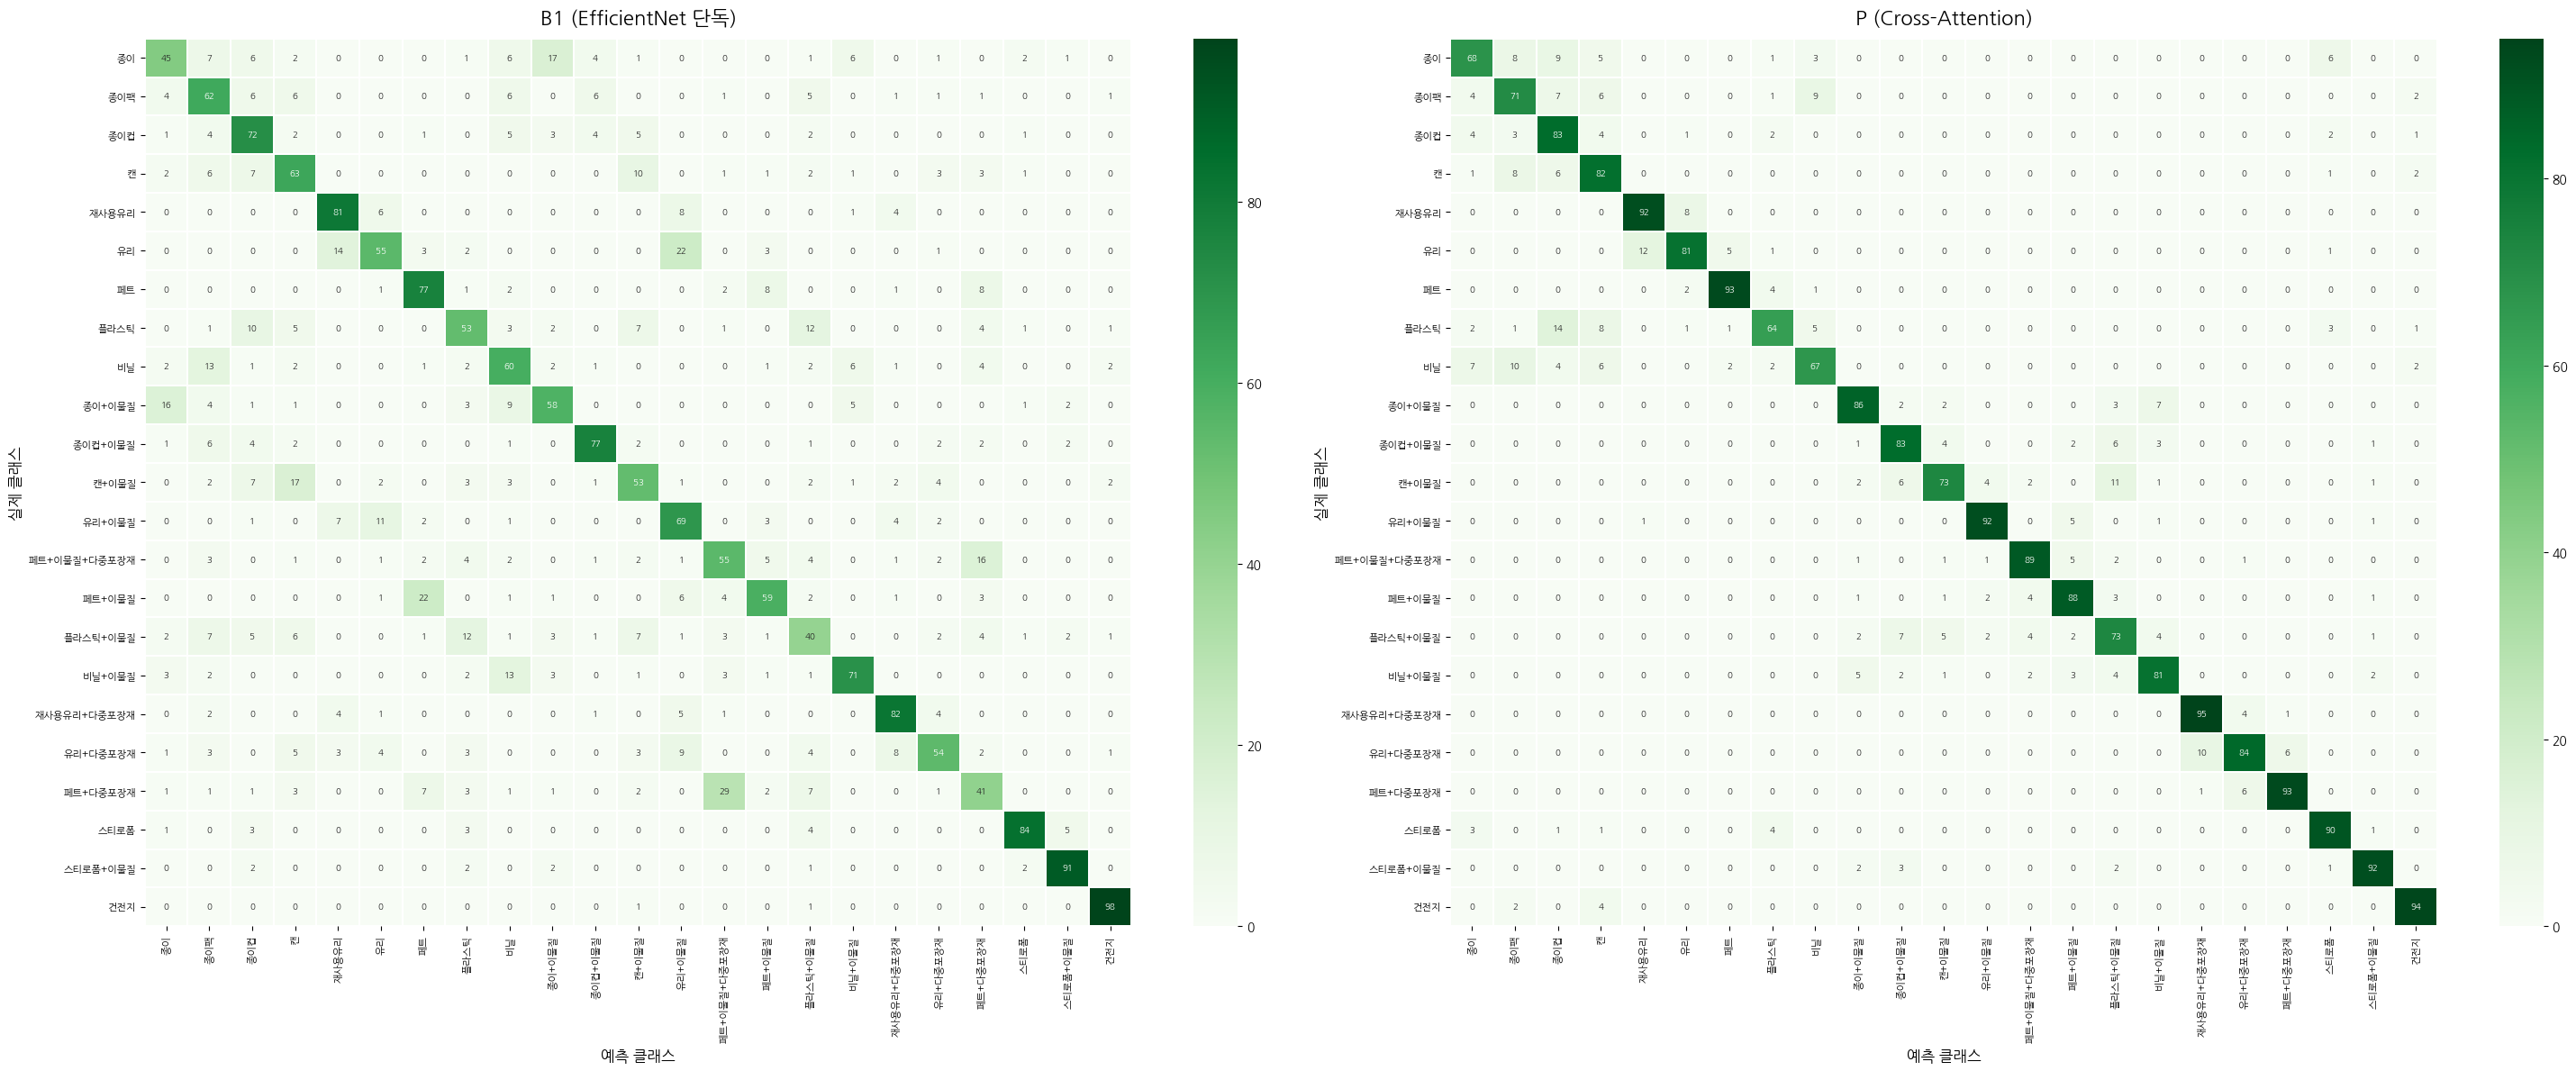

저장 완료: /content/drive/MyDrive/multimodel_recycle/output/confusion_matrix_b1_p.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(30, 12))

for ax, y_pred, title in [
    (axes[0], y_pred_b1, 'B1 (EfficientNet 단독)'),
    (axes[1], y_pred_p,  'P (Cross-Attention)'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=labels, yticklabels=labels,
        ax=ax, annot_kws={'size': 7}, linewidths=0.3
    )
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel('예측 클래스', fontsize=12)
    ax.set_ylabel('실제 클래스', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'confusion_matrix_b1_p.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {save_path}')

## 9. Attention Heatmap 전 레이어 이름 확인

In [ ]:
for layer in model_p.layers:
    print(layer.name)

image
efficientnetb0
input_ids
attention_mask
reshape
tf_roberta_model
img_projection
cross_attention
global_average_pooling1d
dropout_37
dense
dropout_38
dense_1


## 10. Attention Heatmap 함수 정의

In [ ]:
def show_attention(model_p, samples, save_path=None):
    n = len(samples)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4.5 * n))
    if n == 1:
        axes = [axes]

    axes[0][0].set_title('원본 이미지', fontsize=13, fontweight='bold', pad=8)
    axes[0][1].set_title('P Attention Map 오버레이', fontsize=13, fontweight='bold', pad=8)

    for row, (img_path, input_ids, attn_mask, group_name) in enumerate(samples):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img_np = img.numpy().astype(np.uint8)
        img_in = tf.expand_dims(tf.cast(img, tf.float32), 0)

        feat = model_p.get_layer('efficientnetb0')(img_in, training=False)
        feat = tf.reshape(feat, (1, 49, 1280))
        img_proj = model_p.get_layer('img_projection')(feat, training=False)
        txt = model_p.get_layer('tf_roberta_model')(
            input_ids=tf.expand_dims(input_ids, 0),
            attention_mask=tf.expand_dims(attn_mask, 0),
            training=False
        ).last_hidden_state
        _, attn = model_p.get_layer('cross_attention')(
            query=txt, key=img_proj, value=img_proj,
            return_attention_scores=True, training=False
        )
        attn_map = tf.reduce_mean(attn, axis=1)   # 헤드 평균
        attn_map = tf.reduce_mean(attn_map, axis=1)  # 토큰 평균
        attn_map = tf.reshape(attn_map, (1, 7, 7, 1))
        attn_map = tf.image.resize(attn_map, (224, 224)).numpy()[0, :, :, 0]
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

        axes[row][0].imshow(img_np)
        axes[row][0].set_ylabel(group_name, fontsize=11, fontweight='bold', rotation=90, labelpad=8)
        axes[row][0].axis('off')

        axes[row][1].imshow(img_np)
        axes[row][1].imshow(attn_map, alpha=0.55, cmap='jet')
        axes[row][1].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('함수 정의 완료')

함수 정의 완료


## 11. Attention Heatmap 생성 (이물질 클래스 위주)

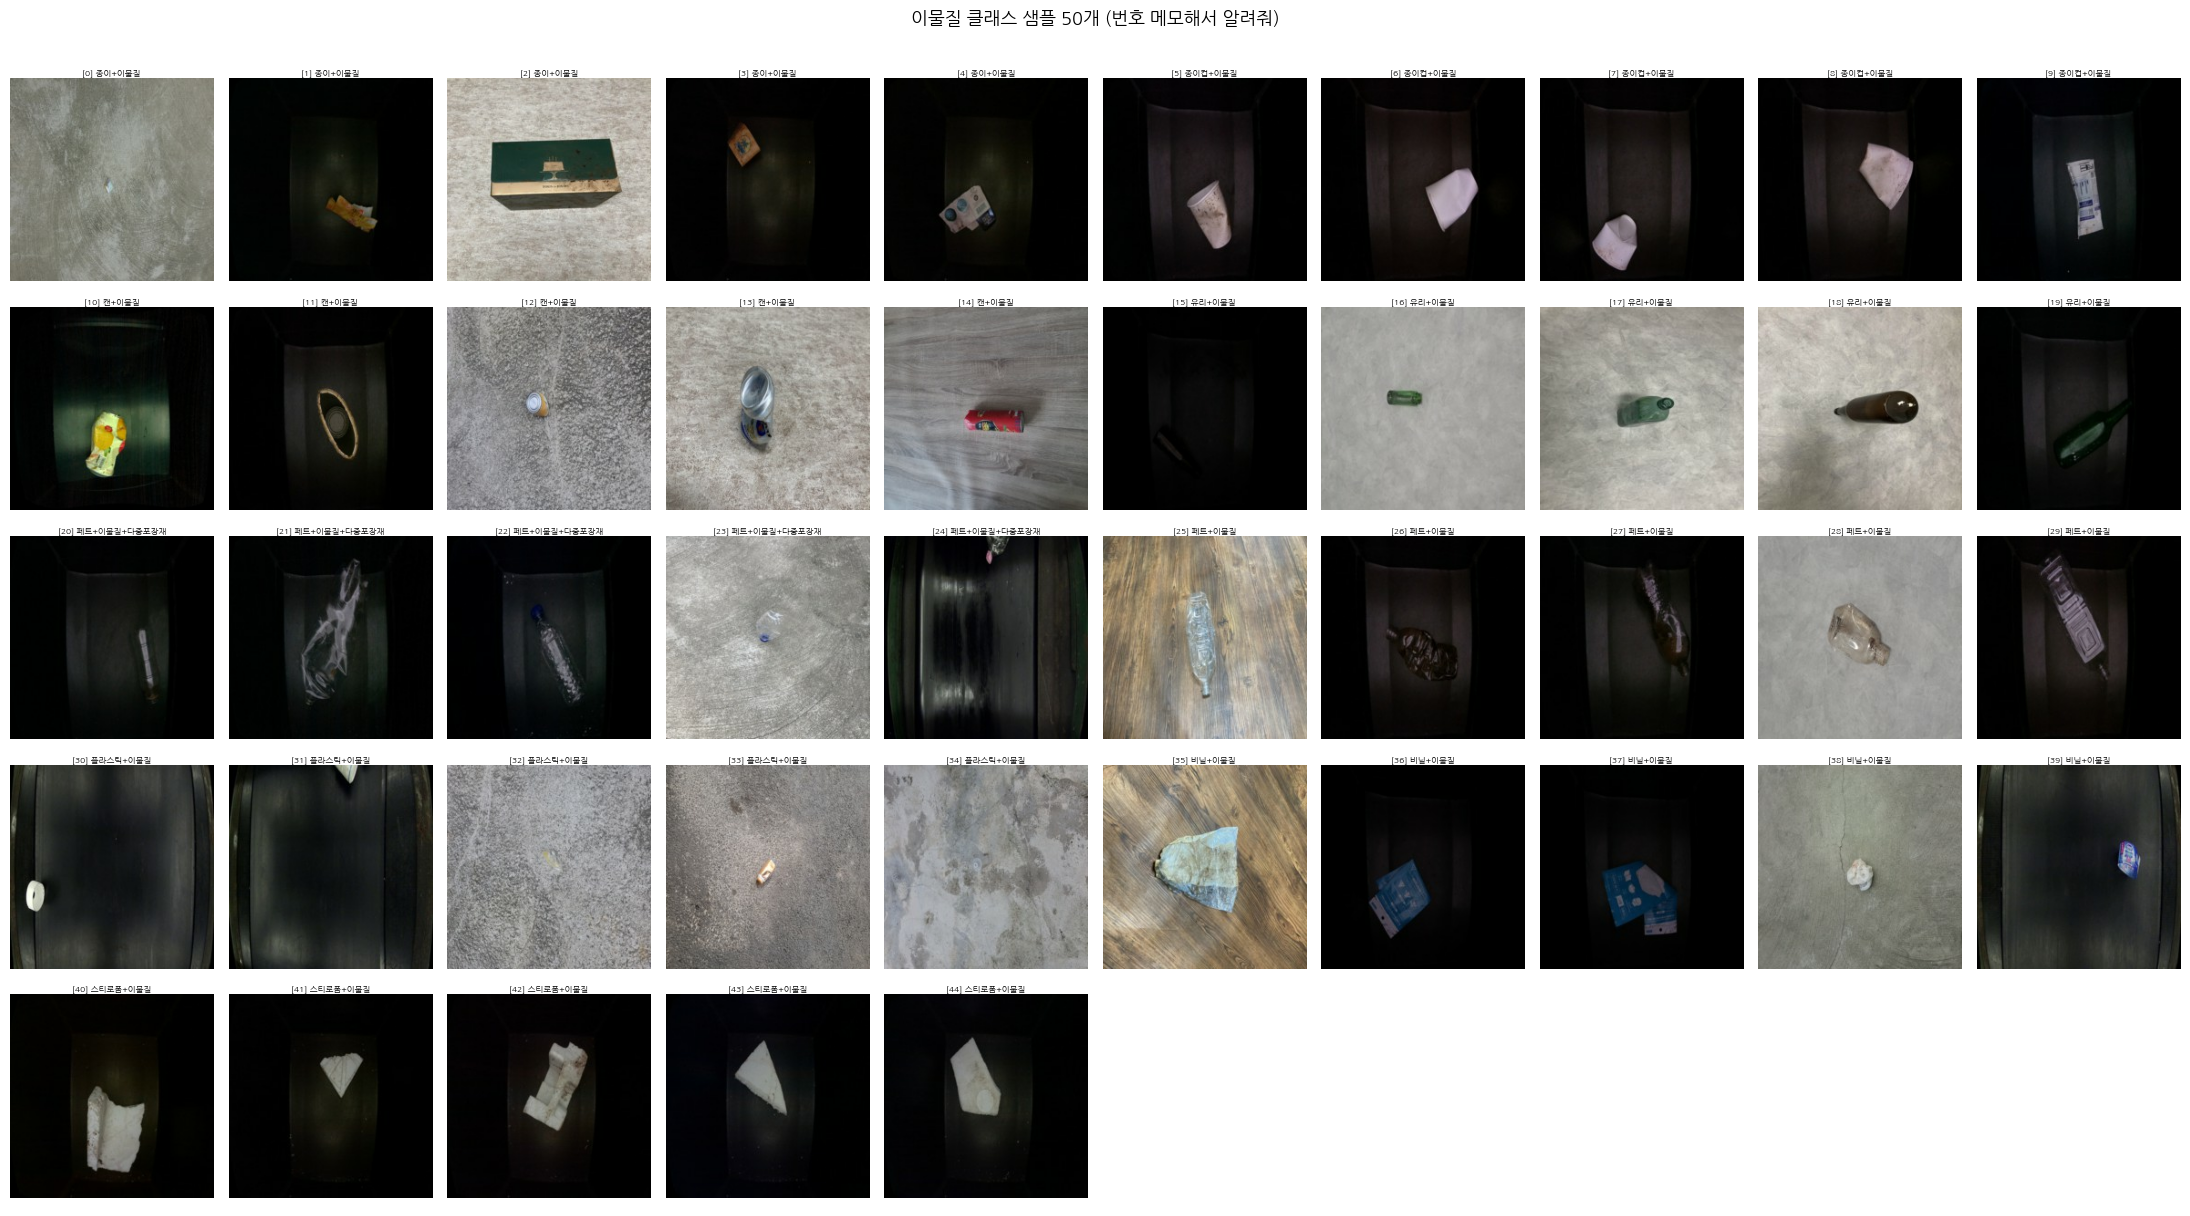

In [ ]:
dirty_classes = {
    9:  '종이+이물질',
    10: '종이컵+이물질',
    11: '캔+이물질',
    12: '유리+이물질',
    13: '페트+이물질+다중포장재',
    14: '페트+이물질',
    15: '플라스틱+이물질',
    16: '비닐+이물질',
    21: '스티로폼+이물질',
}

samples_50 = []
per_class = max(1, 50 // len(dirty_classes))

for gid, gname in dirty_classes.items():
    subset = test_df[test_df['group_id'] == gid].head(per_class)
    for idx in subset.index:
        samples_50.append((idx, gid, gname, test_df.loc[idx, 'img_path']))

samples_50 = samples_50[:50]

ncols = 10
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 12))

for i, (idx, gid, gname, img_path) in enumerate(samples_50):
    row, col = divmod(i, ncols)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3).numpy().astype(np.uint8)
    axes[row][col].imshow(img)
    axes[row][col].set_title(f'[{i}] {gname}', fontsize=6, pad=2)
    axes[row][col].axis('off')

for i in range(len(samples_50), nrows * ncols):
    row, col = divmod(i, ncols)
    axes[row][col].axis('off')

plt.suptitle('이물질 클래스 샘플 50개 (번호 메모해서 알려줘)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dirty_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

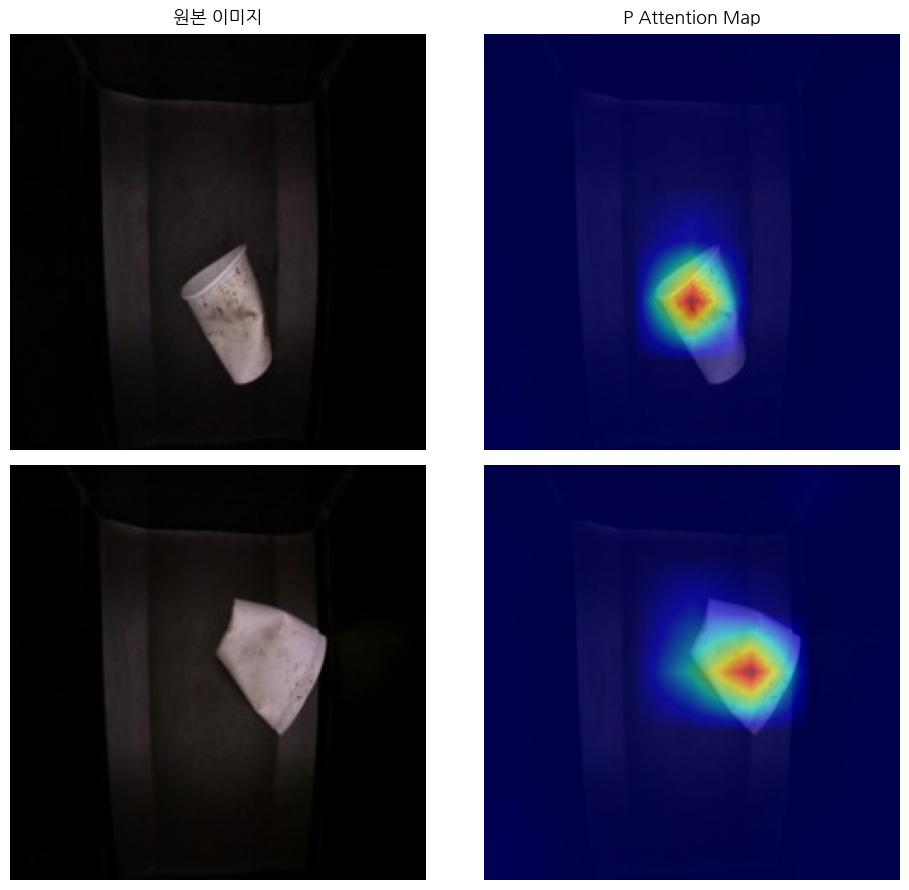

In [ ]:
final_samples = [samples_50[5], samples_50[8]]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes[0][0].set_title('원본 이미지', fontsize=13, fontweight='bold', pad=8)
axes[0][1].set_title('P Attention Map', fontsize=13, fontweight='bold', pad=8)

for row, (idx, gid, gname, img_path) in enumerate(final_samples):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_np = img.numpy().astype(np.uint8)
    img_in = tf.expand_dims(tf.cast(img, tf.float32), 0)

    feat = model_p.get_layer('efficientnetb0')(img_in, training=False)
    feat = tf.reshape(feat, (1, 49, 1280))
    img_proj = model_p.get_layer('img_projection')(feat, training=False)
    txt = model_p.get_layer('tf_roberta_model')(
        input_ids=tf.expand_dims(tf.cast(test_input_ids[idx], tf.int32), 0),
        attention_mask=tf.expand_dims(tf.cast(test_attn_mask[idx], tf.int32), 0),
        training=False
    ).last_hidden_state
    _, attn = model_p.get_layer('cross_attention')(
        query=txt, key=img_proj, value=img_proj,
        return_attention_scores=True, training=False
    )
    attn_map = tf.reduce_mean(attn, axis=1)
    attn_map = tf.reduce_mean(attn_map, axis=1)
    attn_map = tf.reshape(attn_map, (1, 7, 7, 1))
    attn_map = tf.image.resize(attn_map, (224, 224)).numpy()[0, :, :, 0]
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    axes[row][0].imshow(img_np)
    axes[row][0].set_ylabel(gname, fontsize=11, fontweight='bold', rotation=90, labelpad=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(img_np)
    axes[row][1].imshow(attn_map, alpha=0.55, cmap='jet')
    axes[row][1].axis('off')

plt.tight_layout()
plt.show()